In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df = pd.read_csv("../data/Food_Delivery_Times.csv")


In [19]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [21]:
df.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
df["Weather"].fillna(df["Weather"].mode()[0], inplace=True)

df["Traffic_Level"].fillna(df["Traffic_Level"].mode()[0], inplace=True)

df["Time_of_Day"].fillna(df["Time_of_Day"].mode()[0], inplace=True)

df["Courier_Experience_yrs"].fillna(df["Courier_Experience_yrs"].mean(), inplace=True)

C:\Users\kaviya\AppData\Local\Temp\ipykernel_19864\1569497219.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Weather"].fillna(df["Weather"].mode()[0], inplace=True)
C:\Users\kaviya\AppData\Local\Temp\ipykernel_19864\1569497219.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a c

In [24]:
df.isnull().sum()


Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64

In [25]:
df["Delivery_Time_min"].mean()

np.float64(56.732)

In [26]:
df["Delivery_Time_min"].median()

np.float64(55.5)

In [27]:
df["Delivery_Time_min"].mode()

0    71
Name: Delivery_Time_min, dtype: int64

In [28]:
df["Delivery_Time_min"].std()

np.float64(22.07091528009886)

In [29]:
df["Delivery_Time_min"].var()

np.float64(487.12530130130136)

In [30]:
df["Delivery_Time_min"].describe()

count    1000.000000
mean       56.732000
std        22.070915
min         8.000000
25%        41.000000
50%        55.500000
75%        71.000000
max       153.000000
Name: Delivery_Time_min, dtype: float64

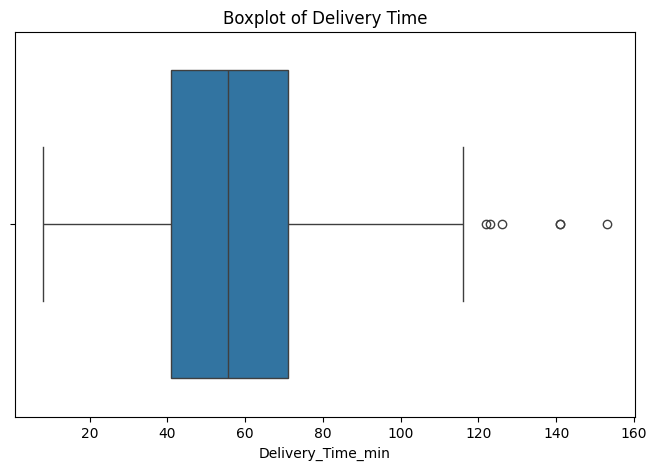

In [31]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Delivery_Time_min"])
plt.title("Boxplot of Delivery Time")
plt.show()

In [32]:
Q1 = df["Delivery_Time_min"].quantile(0.25)
Q3 = df["Delivery_Time_min"].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 41.0
Q3: 71.0
IQR: 30.0


In [33]:
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Lower Limit: -4.0
Upper Limit: 116.0


In [34]:
outliers = df[(df["Delivery_Time_min"] < lower_limit) | 
              (df["Delivery_Time_min"] > upper_limit)]

outliers

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
29,948,18.05,Clear,Medium,Evening,Scooter,10,7.0,123
127,446,18.97,Clear,Low,Evening,Car,25,4.0,141
379,814,18.46,Clear,Medium,Morning,Scooter,29,1.0,153
452,394,15.64,Rainy,Low,Morning,Bike,20,4.0,141
784,385,14.83,Rainy,Low,Morning,Car,19,4.0,126
924,428,17.81,Windy,High,Evening,Bike,21,4.0,122


In [35]:
from scipy.stats import zscore

In [36]:
df["z_score"] = zscore(df["Delivery_Time_min"])

df[["Delivery_Time_min", "z_score"]].head()

,Delivery_Time_min,z_score
0,43,-0.622488
1,84,1.236090
2,59,0.102811
3,37,-0.894475
4,68,0.510792


In [37]:
z_outliers = df[(df["z_score"] > 3) | (df["z_score"] < -3)]
z_outliers

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,z_score
29,948,18.05,Clear,Medium,Evening,Scooter,10,7.0,123,3.004006
127,446,18.97,Clear,Low,Evening,Car,25,4.0,141,3.819967
379,814,18.46,Clear,Medium,Morning,Scooter,29,1.0,153,4.363941
452,394,15.64,Rainy,Low,Morning,Bike,20,4.0,141,3.819967
784,385,14.83,Rainy,Low,Morning,Car,19,4.0,126,3.139999


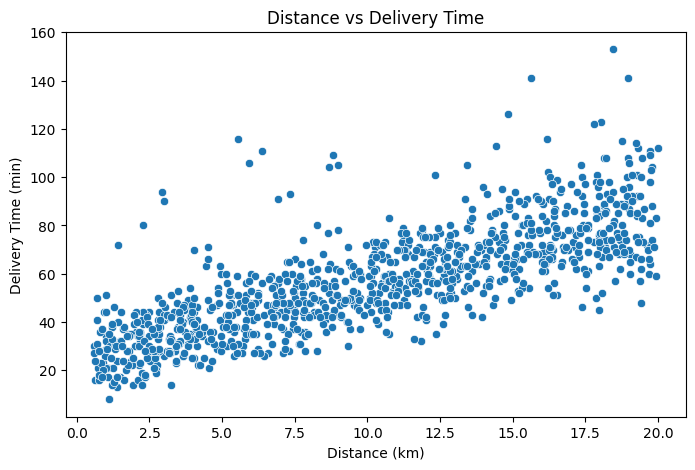

In [38]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["Distance_km"],
    y=df["Delivery_Time_min"]
)

plt.title("Distance vs Delivery Time")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (min)")

plt.show()

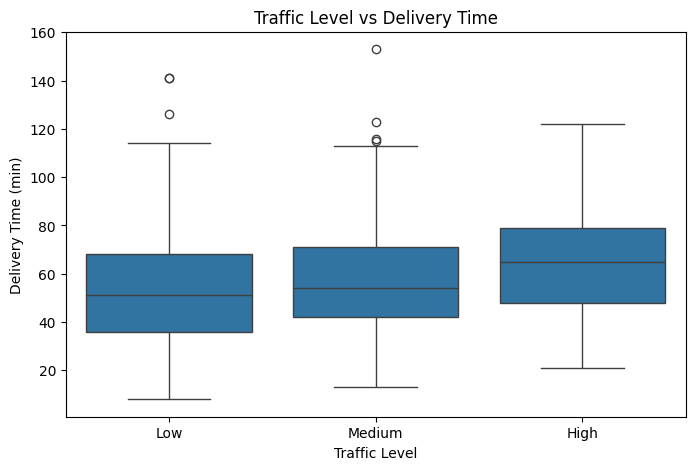

In [39]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Traffic_Level"],
    y=df["Delivery_Time_min"]
)

plt.title("Traffic Level vs Delivery Time")
plt.xlabel("Traffic Level")
plt.ylabel("Delivery Time (min)")

plt.show()

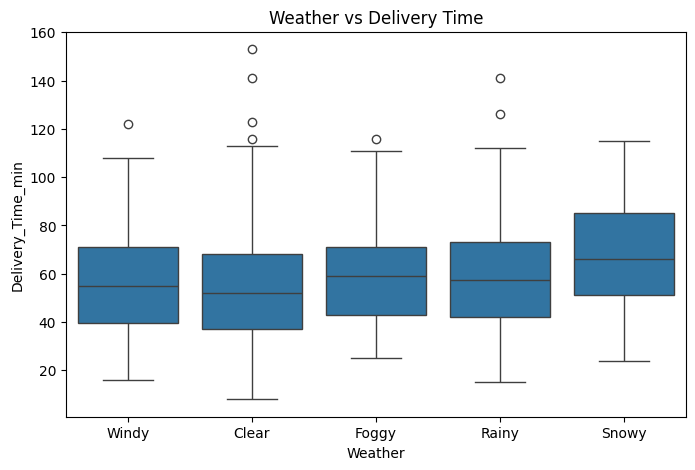

In [40]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Weather"],
    y=df["Delivery_Time_min"]
)

plt.title("Weather vs Delivery Time")

plt.show()

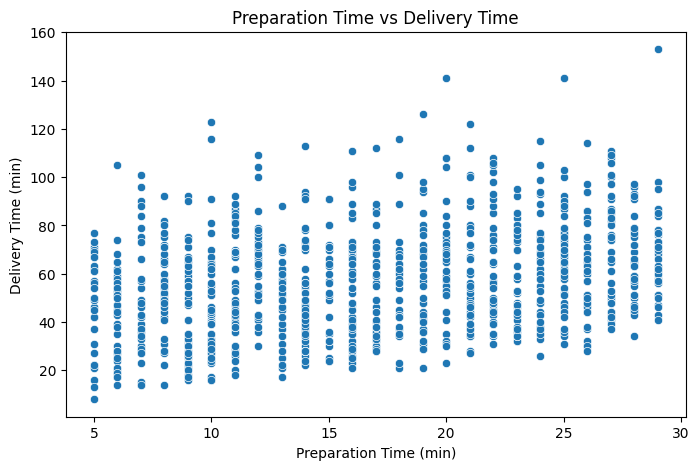

In [41]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["Preparation_Time_min"],
    y=df["Delivery_Time_min"]
)

plt.title("Preparation Time vs Delivery Time")
plt.xlabel("Preparation Time (min)")
plt.ylabel("Delivery Time (min)")

plt.show()

In [42]:
correlation = df[[
    "Distance_km",
    "Preparation_Time_min",
    "Courier_Experience_yrs",
    "Delivery_Time_min"
]].corr()

correlation

,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
Distance_km,1.000000,-0.009037,-0.007713,0.780998
Preparation_Time_min,-0.009037,1.000000,-0.030353,0.307350
Courier_Experience_yrs,-0.007713,-0.030353,1.000000,-0.089066
Delivery_Time_min,0.780998,0.307350,-0.089066,1.000000


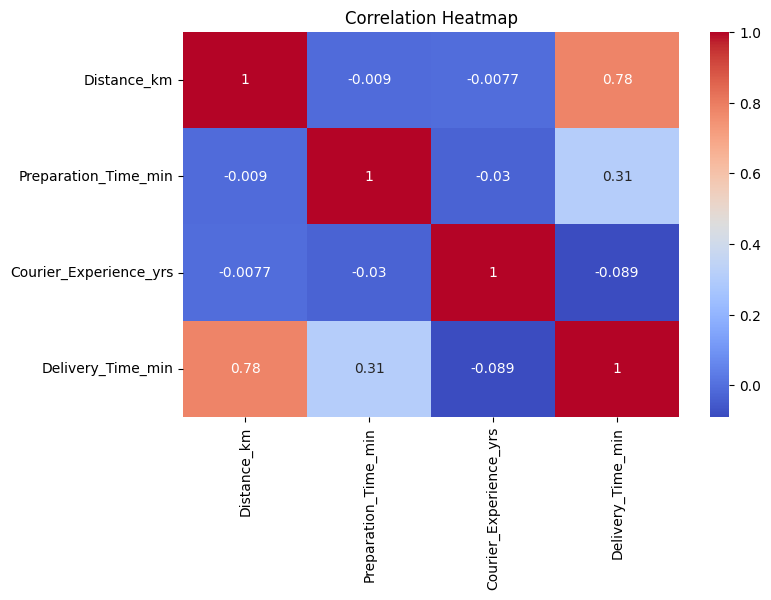

In [43]:
plt.figure(figsize=(8,5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [44]:
from scipy.stats import f_oneway

In [45]:
clear = df[df["Weather"] == "Clear"]["Delivery_Time_min"]
rainy = df[df["Weather"] == "Rainy"]["Delivery_Time_min"]
foggy = df[df["Weather"] == "Foggy"]["Delivery_Time_min"]


In [46]:
print("Clear:", len(clear))
print("Rainy:", len(rainy))
print("Foggy:", len(foggy))

Clear: 500
Rainy: 204
Foggy: 103


In [48]:
anova_result = f_oneway(clear, rainy, foggy)

In [49]:
print("\nANOVA Result:")
print(anova_result)


ANOVA Result:
F_onewayResult(statistic=np.float64(8.636127148227493), pvalue=np.float64(0.00019457942395118173))


In [50]:
print(df.columns)

Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min', 'z_score'],
      dtype='object')


In [51]:
df.info

<bound method DataFrame.info of      Order_ID  Distance_km Weather Traffic_Level Time_of_Day Vehicle_Type  \
0         522         7.93   Windy           Low   Afternoon      Scooter   
1         738        16.42   Clear        Medium     Evening         Bike   
2         741         9.52   Foggy           Low       Night      Scooter   
3         661         7.44   Rainy        Medium   Afternoon      Scooter   
4         412        19.03   Clear           Low     Morning         Bike   
..        ...          ...     ...           ...         ...          ...   
995       107         8.50   Clear          High     Evening          Car   
996       271        16.28   Rainy           Low     Morning      Scooter   
997       861        15.62   Snowy          High     Evening      Scooter   
998       436        14.17   Clear           Low   Afternoon         Bike   
999       103         6.63   Foggy           Low       Night      Scooter   

     Preparation_Time_min  Courier_Experien

Business Insights

1. What factors contribute most to delays?

The primary factors contributing to delays are delivery distance, traffic conditions, and preparation time. Distance shows the strongest correlation with delivery time, followed by preparation time. When the distance increases, delivery time tends to increase significantly. 

2. Which city has the highest delays?

City-wise analysis could not be performed because the dataset does not contain a city column. Therefore, it is not possible to determine which city experiences the highest delivery delays.

3. Does bad weather impact delivery time?

Yes. Weather conditions have a significant impact on delivery time. The ANOVA test produced a p-value of 0.00019, which is less than the significance level of 0.05. This indicates that adverse weather conditions such as rain, fog, and snow contribute to increased delivery delays.

4. Are highly rated delivery partners faster?

The dataset does not contain a "Rider Rating" column, so we couldn’t assess the performance based on ratings. However, we did observe that courier experience has a weak negative correlation with delivery time—slightly more experienced couriers tend to be a bit faster.

5. What recommendations would you give operations teams?

Based on the analysis, the following recommendations are suggested:

1) Optimize delivery routes to reduce travel time for long-distance orders.

2) Increase delivery partner availability during peak traffic periods.

3) Improve restaurant preparation efficiency to minimize waiting time before dispatch.

4) Implement weather-aware delivery planning during rainy, foggy, or snowy conditions.

5) Monitor and investigate extreme delivery delays to identify operational bottlenecks.

6) Provide additional training and support for less experienced couriers to improve overall delivery efficiency.
